In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi
# reading in/preprocessing data
analysis_data = pd.read_csv("pff_data_updated.csv")
analysis_data = analysis_data.drop(columns=['Unnamed: 0'])
analysis_grades = analysis_data[["player", "position", "grades_defense", "grades_pass_rush_defense", "grades_run_defense", "grades_tackle"]]
analysis_stats_raw = analysis_data[["player", "position", "snap_counts_defense", "tackles", "total_pressures", "hits", "hurries", "missed_tackles", "sacks", "snap_counts_pass_rush"
                                    ,"snap_counts_run_defense"]]

In [9]:
# calculating stats per snap
analysis_stats_normalized = analysis_stats_raw.copy()
for stat in ["tackles", "total_pressures", "hits", "hurries", "sacks", "missed_tackles"]:
    analysis_stats_normalized[f"{stat}_per_100_snaps"] = round(analysis_stats_normalized[stat] * 100 / analysis_stats_normalized["snap_counts_defense"], 3)

In [10]:
# splitting linebackers and dline for final analysis
subset_linebackers_final = ['Jackson Forrest',  'Bryce Deas', 'Noah Chambers', 'Carlton Smith']
subset_dline_final = ['Kris Jones', 'Carson Tujague', 'Chris Forbes', 'Bryce Jenkins', 'Zahir Mathis', 'Sidney Stewart']
final_analysis_lbs = analysis_stats_normalized[analysis_stats_normalized['player'].isin(subset_linebackers_final)]
final_grades_lbs = analysis_grades[analysis_grades['player'].isin(subset_linebackers_final)]
final_analysis_dline = analysis_stats_normalized[analysis_stats_normalized['player'].isin(subset_dline_final)]
final_grades_dline = analysis_grades[analysis_grades['player'].isin(subset_dline_final)]

In [11]:

# ============================================================
# UVA COLOR PALETTE
# ============================================================
UVA_NAVY   = '#232D4B'
UVA_ORANGE = '#F84C1E'
UVA_WHITE  = '#FFFFFF'
UVA_LTGRAY = '#B0B7BC'
UVA_DKGRAY = '#4B5966'
UVA_CREAM  = '#F5F0E1'

LB_COLORS = ['#F84C1E', '#FF9E1B', '#E8723A', '#FFD199']
DL_COLORS = ['#F84C1E', '#FF9E1B', '#E8723A', '#FFD199', '#C75B12']

# UVA Grade Averages
UVA_ovr_avg       = 69.05
UVA_pass_rush_avg = 64.35
UVA_run_def_avg   = 68.3
UVA_tackle_avg    = 62.65

# ============================================================
# CORRECT COLUMN MAPPINGS
# ============================================================
grade_cols   = ['grades_defense', 'grades_pass_rush_defense',
                'grades_run_defense', 'grades_tackle']
grade_labels = ['Overall Defense', 'Pass Rush', 'Run Defense', 'Tackling']
uva_grade_avgs = [UVA_ovr_avg, UVA_pass_rush_avg, UVA_run_def_avg, UVA_tackle_avg]

stat_cols   = ['tackles_per_100_snaps', 'total_pressures_per_100_snaps',
               'sacks_per_100_snaps', 'hits_per_100_snaps',
               'hurries_per_100_snaps', 'missed_tackles_per_100_snaps']
stat_labels = ['Tackles /100', 'Pressures /100', 'Sacks /100',
               'Hits /100', 'Hurries /100', 'Missed Tkl /100']

# ============================================================
# GLOBAL STYLE
# ============================================================
def set_uva_style():
    plt.rcParams.update({
        'figure.facecolor': UVA_WHITE,
        'axes.facecolor': UVA_CREAM,
        'axes.edgecolor': UVA_NAVY,
        'axes.labelcolor': UVA_NAVY,
        'axes.titleweight': 'bold',
        'text.color': UVA_NAVY,
        'xtick.color': UVA_NAVY,
        'ytick.color': UVA_NAVY,
        'font.family': 'sans-serif',
        'font.size': 11,
        'axes.grid': True,
        'grid.color': UVA_LTGRAY,
        'grid.alpha': 0.5,
    })

set_uva_style()

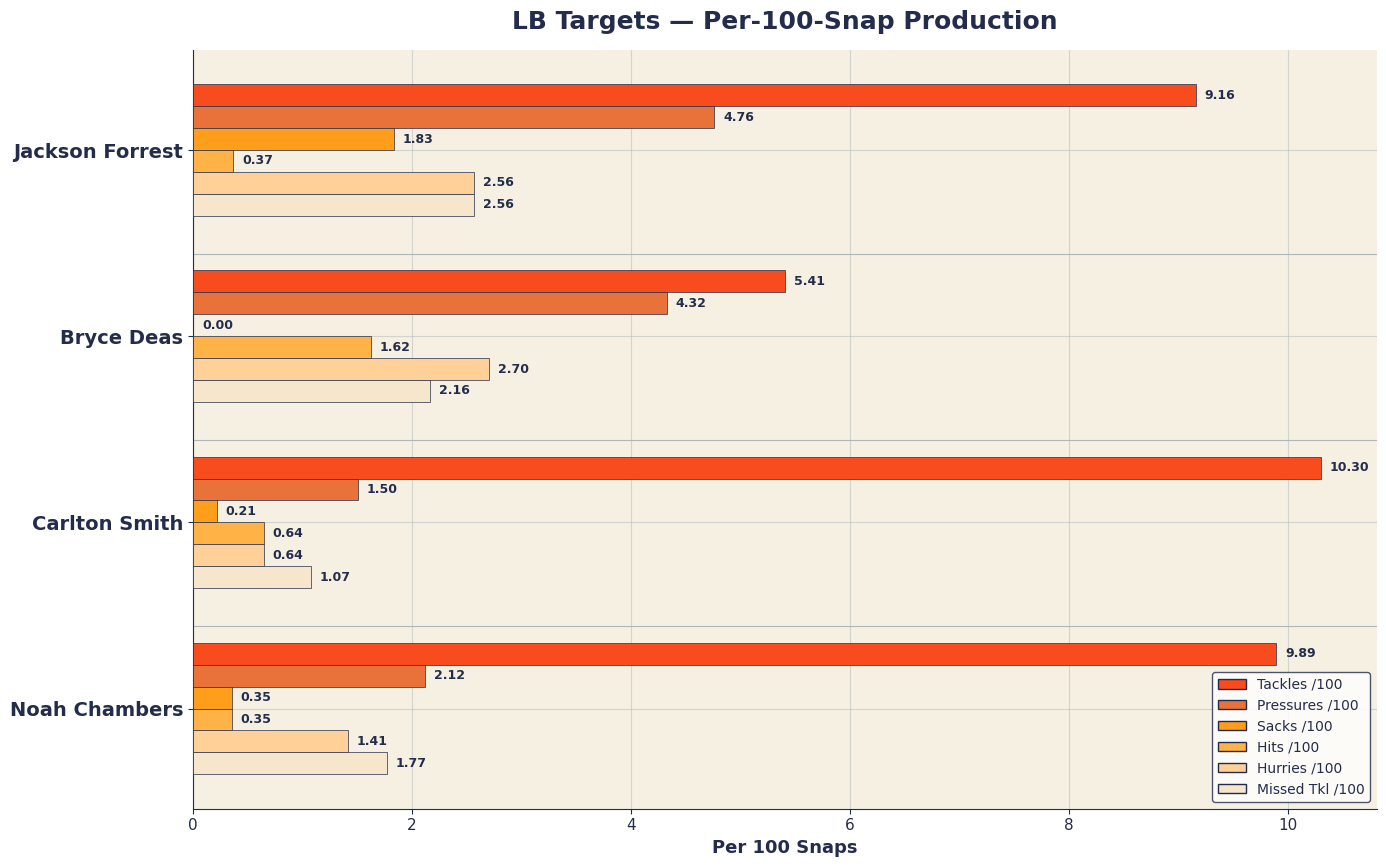

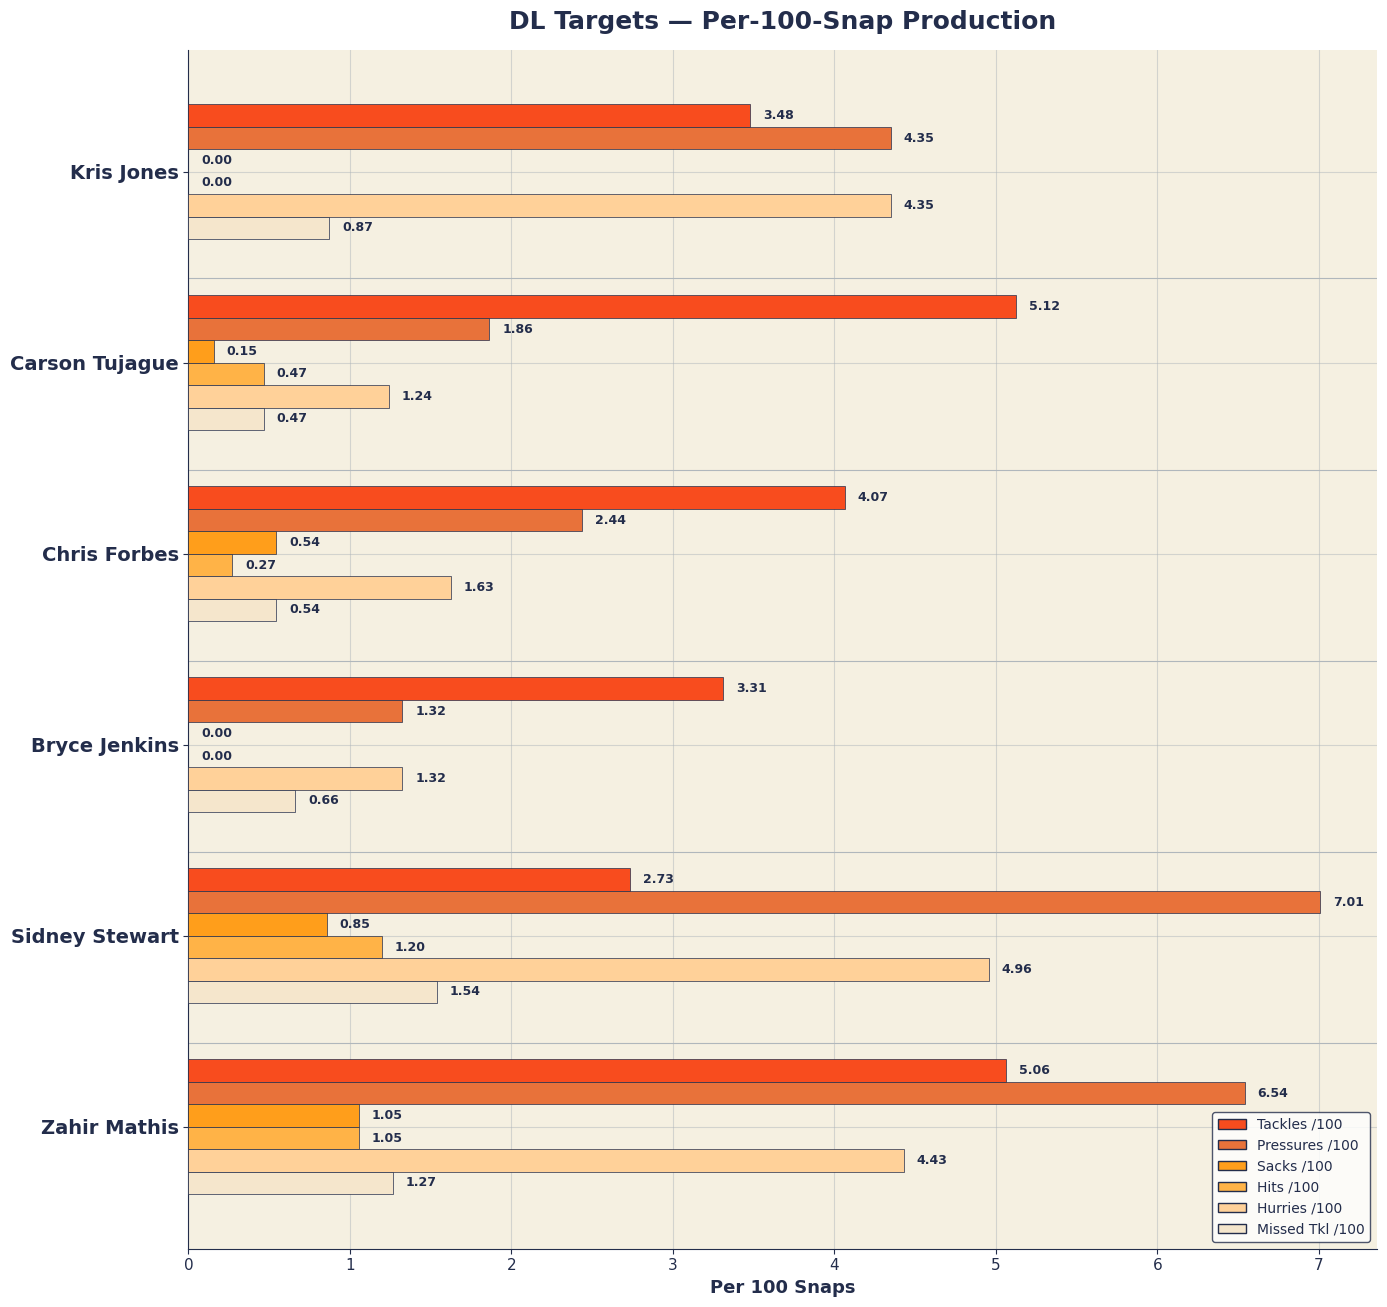

In [12]:
def grouped_bars_by_player(df, colors, title):
    players   = df['player'].tolist()
    n_stats   = len(stat_cols)
    n_players = len(players)
    bar_h     = 0.12
    group_gap = 0.3  # space between player clusters
    
    fig, ax = plt.subplots(figsize=(14, max(7, n_players * 2.2)))
    fig.patch.set_facecolor(UVA_WHITE)
    ax.set_facecolor(UVA_CREAM)

    # Stat colors — gradient from UVA orange to light gold
    stat_colors = ['#F84C1E', '#E8723A', '#FF9E1B', '#FFB347', '#FFD199', '#F5E6CC']

    ytick_positions = []
    ytick_labels    = []
    y_cursor        = 0

    for p_idx, (_, row) in enumerate(df.iterrows()):
        vals = [row[c] for c in stat_cols]

        for s_idx in range(n_stats):
            y_pos = y_cursor + s_idx * bar_h
            ax.barh(y_pos, vals[s_idx], height=bar_h,
                    color=stat_colors[s_idx % len(stat_colors)],
                    edgecolor=UVA_NAVY, linewidth=0.5, zorder=3)
            # Value annotation
            ax.text(vals[s_idx] + 0.08, y_pos, f'{vals[s_idx]:.2f}',
                    va='center', fontsize=9, color=UVA_NAVY, fontweight='bold')

        # Player label at center of their cluster
        cluster_center = y_cursor + (n_stats - 1) * bar_h / 2
        ytick_positions.append(cluster_center)
        ytick_labels.append(row['player'])

        # Divider line between players
        if p_idx < n_players - 1:
            divider_y = y_cursor + n_stats * bar_h + group_gap / 2
            ax.axhline(y=divider_y, color=UVA_LTGRAY, linewidth=0.8,
                       linestyle='-', zorder=1)

        y_cursor += n_stats * bar_h + group_gap

    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels, fontsize=14, fontweight='bold',
                       color=UVA_NAVY)
    ax.invert_yaxis()
    ax.set_xlabel('Per 100 Snaps', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=18, fontweight='bold',
                 color=UVA_NAVY, pad=15)

    # Legend for stat categories
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=stat_colors[i], edgecolor=UVA_NAVY,
                            label=stat_labels[i])
                      for i in range(n_stats)]
    legend = ax.legend(handles=legend_handles, loc='lower right',
                       frameon=True, fontsize=10,
                       facecolor=UVA_WHITE, edgecolor=UVA_NAVY)
    for t in legend.get_texts():
        t.set_color(UVA_NAVY)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'bars_{title.replace(" ","_").lower()}.png',
                dpi=200, bbox_inches='tight')
    plt.show()


# --- RUN ---
grouped_bars_by_player(final_analysis_lbs, LB_COLORS,
                       'LB Targets — Per-100-Snap Production')

grouped_bars_by_player(final_analysis_dline, DL_COLORS,
                       'DL Targets — Per-100-Snap Production')

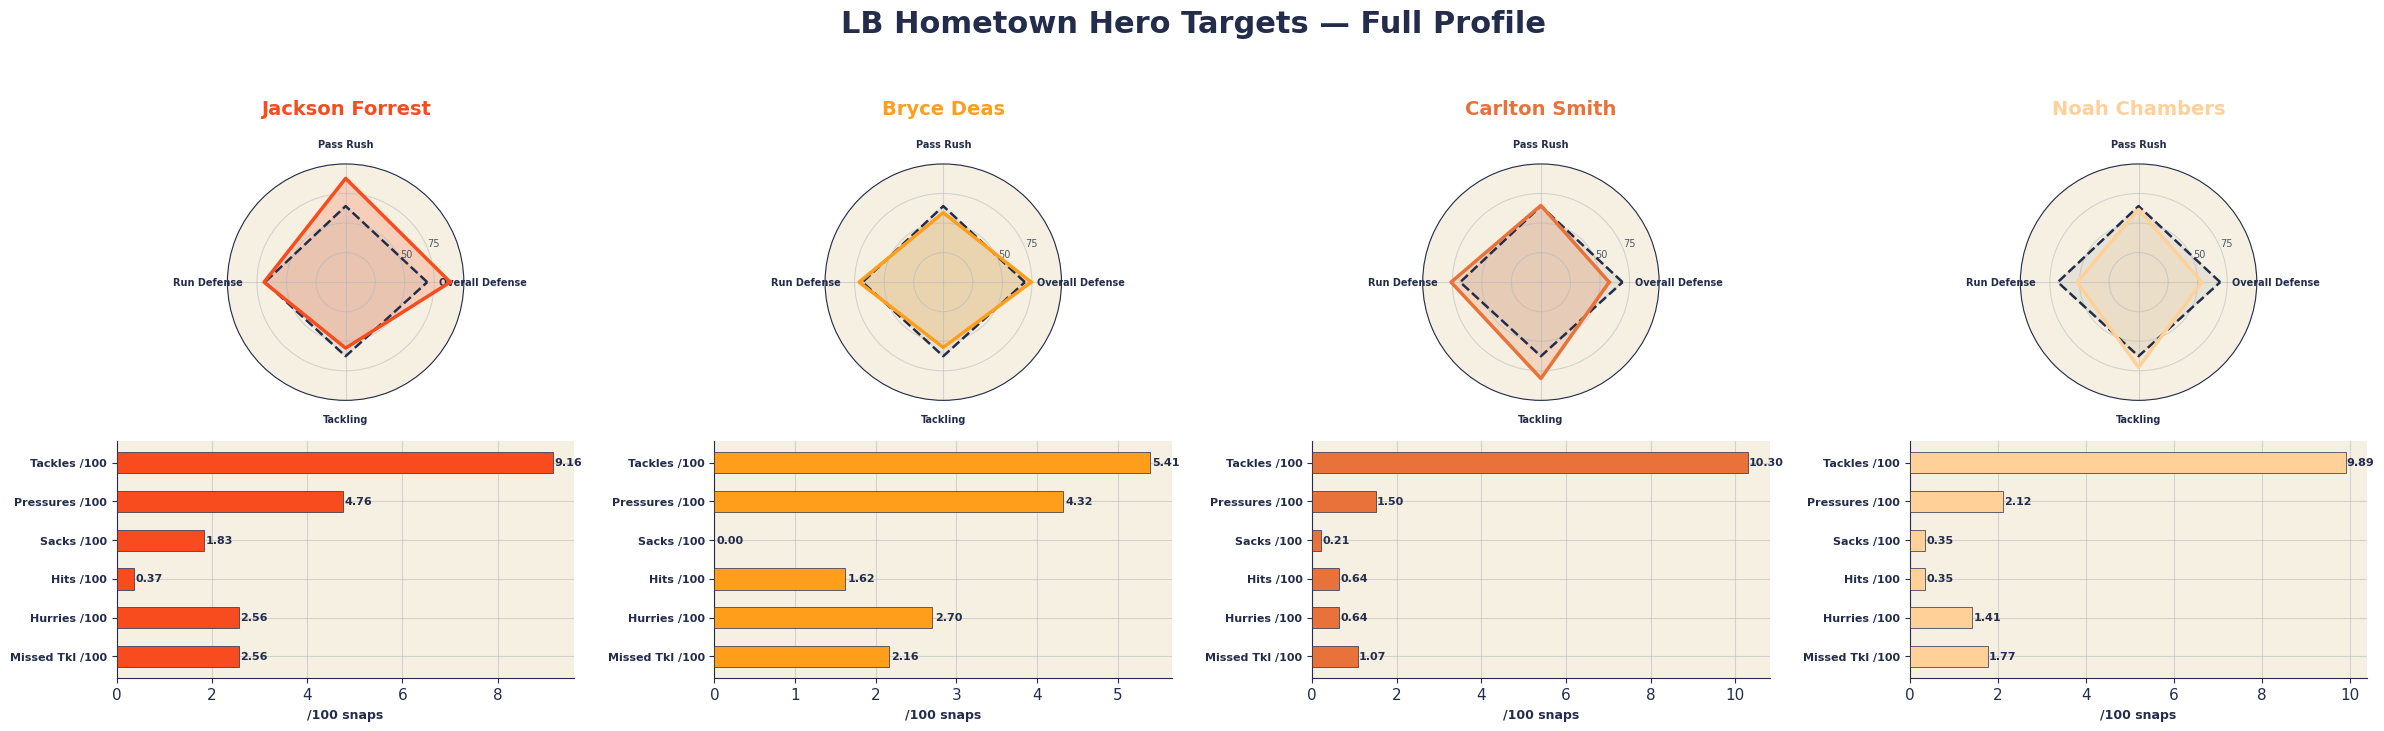

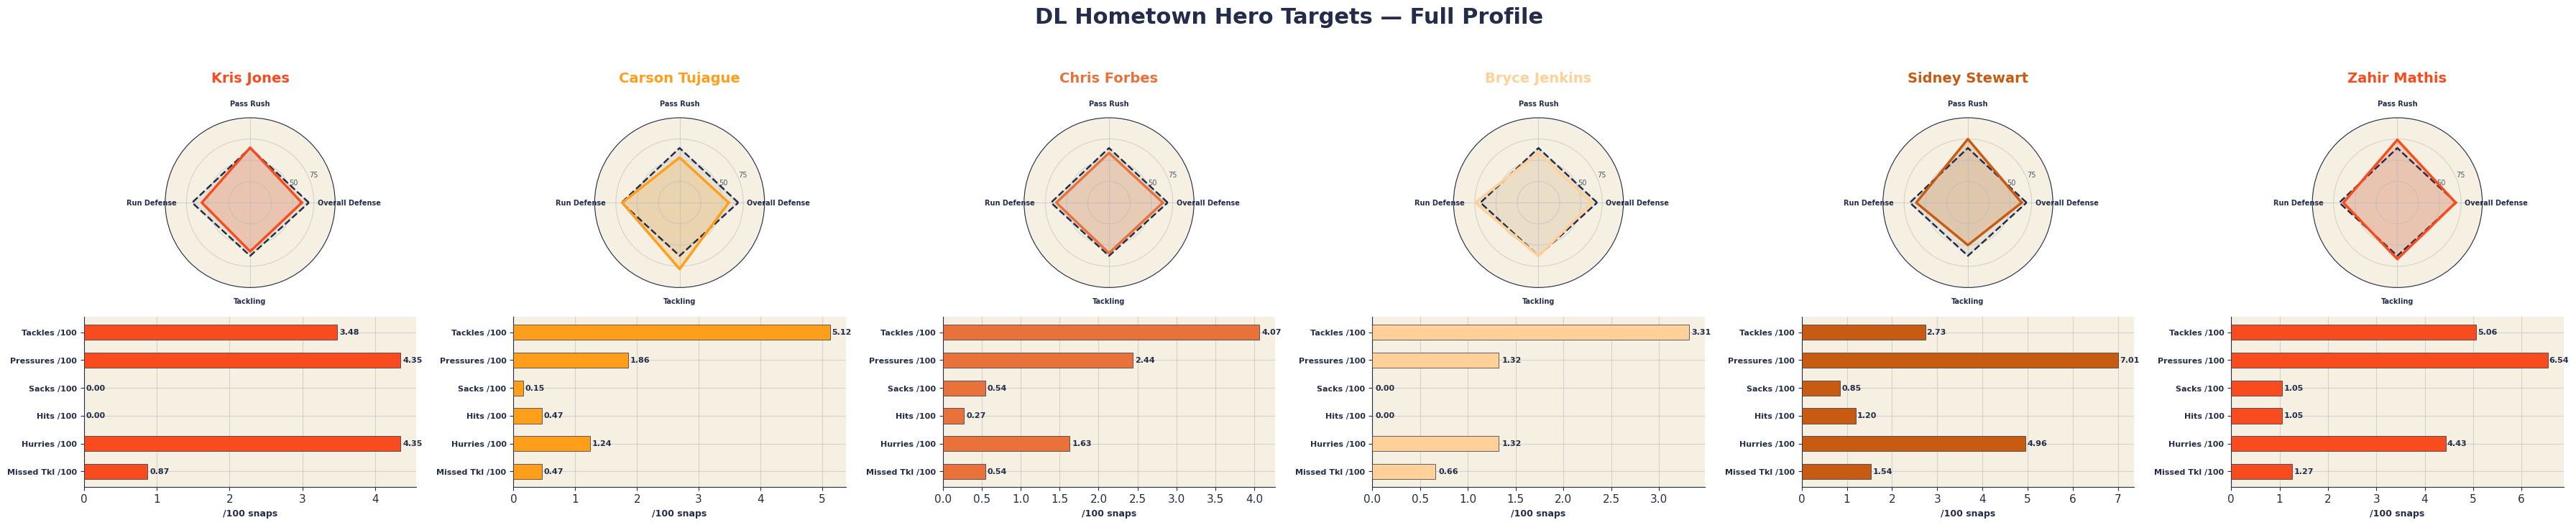

In [7]:
# ============================================================
# FULL DASHBOARD — One card per player, radar left + bar right
# ============================================================
def player_dashboard(grades_df, stats_df, colors, suptitle):
    players  = grades_df['player'].tolist()
    n        = len(players)

    fig = plt.figure(figsize=(6 * n, 7))
    fig.patch.set_facecolor(UVA_WHITE)
    fig.suptitle(suptitle, fontsize=22, fontweight='bold',
                 color=UVA_NAVY, y=1.04)

    for idx, name in enumerate(players):
        color = colors[idx % len(colors)]

        # ---- TOP: RADAR (grades) ----
        ax_r = fig.add_subplot(2, n, idx + 1, polar=True)
        ax_r.set_facecolor(UVA_CREAM)

        N = len(grade_labels)
        angles = [x / float(N) * 2 * pi for x in range(N)]
        angles += angles[:1]

        # UVA avg
        uva_v = uva_grade_avgs + uva_grade_avgs[:1]
        ax_r.plot(angles, uva_v, linewidth=1.8, linestyle='--',
                  color=UVA_NAVY, zorder=3)
        ax_r.fill(angles, uva_v, alpha=0.07, color=UVA_NAVY)

        # Player
        row_g = grades_df[grades_df['player'] == name].iloc[0]
        vals  = [row_g[c] for c in grade_cols] + [row_g[grade_cols[0]]]
        ax_r.plot(angles, vals, linewidth=2.5, color=color, zorder=4)
        ax_r.fill(angles, vals, alpha=0.20, color=color)

        ax_r.set_xticks(angles[:-1])
        ax_r.set_xticklabels(grade_labels, fontsize=7, fontweight='bold')
        ax_r.set_ylim(0, 100)
        ax_r.set_yticks([25, 50, 75, 100])
        ax_r.set_yticklabels(['', '50', '75', ''], fontsize=7,
                              color=UVA_DKGRAY)
        ax_r.set_title(name, fontsize=14, fontweight='bold',
                       color=color, pad=18)

        # ---- BOTTOM: BAR (per-100 stats) ----
        ax_b = fig.add_subplot(2, n, n + idx + 1)
        ax_b.set_facecolor(UVA_CREAM)

        row_s = stats_df[stats_df['player'] == name].iloc[0]
        vals_s = [row_s[c] for c in stat_cols]
        y_pos  = np.arange(len(stat_cols))

        ax_b.barh(y_pos, vals_s, color=color, edgecolor=UVA_NAVY,
                  linewidth=0.5, height=0.55, zorder=3)

        for y, v in zip(y_pos, vals_s):
            ax_b.text(v + 0.03, y, f'{v:.2f}', va='center',
                      fontsize=8, color=UVA_NAVY, fontweight='bold')

        ax_b.set_yticks(y_pos)
        ax_b.set_yticklabels(stat_labels, fontsize=8, fontweight='bold')
        ax_b.invert_yaxis()
        ax_b.set_xlabel('/100 snaps', fontsize=9, fontweight='bold')
        ax_b.spines['top'].set_visible(False)
        ax_b.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'dashboard_{suptitle.replace(" ","_").lower()}.png',
                dpi=200, bbox_inches='tight')
    plt.show()


# --- RUN ---
player_dashboard(final_grades_lbs, final_analysis_lbs, LB_COLORS,
                 'LB Hometown Hero Targets — Full Profile')

player_dashboard(final_grades_dline, final_analysis_dline, DL_COLORS,
                 'DL Hometown Hero Targets — Full Profile')